# 1 · Eval Results  `[EVAL]`

The full-conversation outcomes and the head-to-head method / look-ahead contrasts, as figures. Did each arm improve over base, how does the whole learning curve look, and how do PTO vs GRPO and K=0 vs K=5 compare? Verdicts in prose; the exact statistics live in `6_Detailed_Stats`.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath("."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, pref, figures, plots
S = exp3.notebook_setup()

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 6), ('GRPO_LA0', 6), ('GRPO_LA5', 2)]
scores_long: (16128, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
exports -> C:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results


## 1 · Outcome trajectories  `[EVAL]`
**Purpose.** Per-rubric mean +/- 95% CI across iterations, arms overlaid (all iterations shown). **Read:** the caption flags that the 6 rubrics load on ~one factor (PC1~91%), so a uniform rise is one warmth/satisfaction axis, not six independent skills.

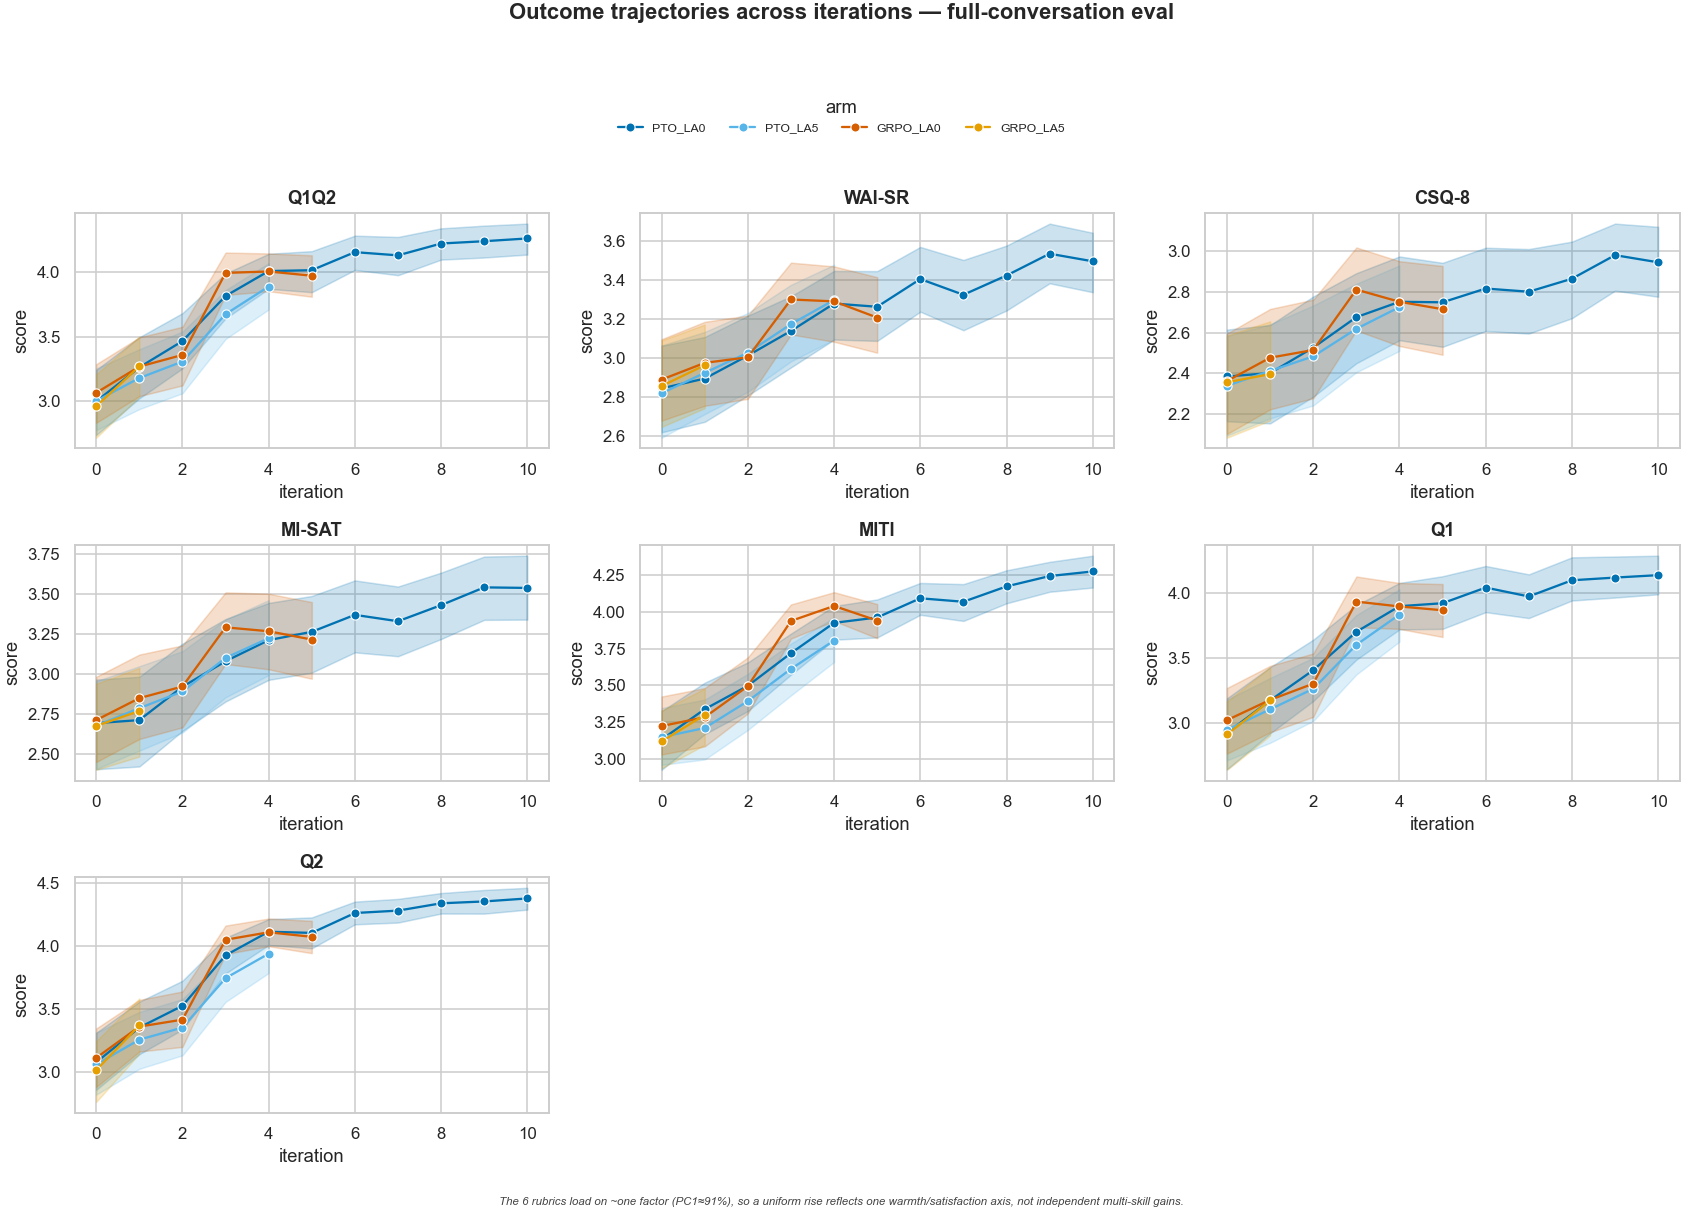

In [2]:
fig = plots.trajectory_grid(S.SCORES, palette=S.PALETTE)
exp3.save_fig(fig, "trajectories_all_rubrics", caption="Full-conversation eval: per-rubric mean +/- 95% CI across iterations, arms overlaid. The 6 rubrics load on ~one factor (PC1~91%), so a uniform rise reflects one latent axis."); plt.show()

## 2 · Subscale trajectories  `[EVAL]`
**Purpose.** Open up the rubric means: one line per WAI/MITI sub-scale across iterations, a panel per (parent, arm). **Read:** shows whether relational warmth (Bond/Partnership/Empathy) rises faster than change-oriented skill (Goal/Cultivating-Change-Talk).

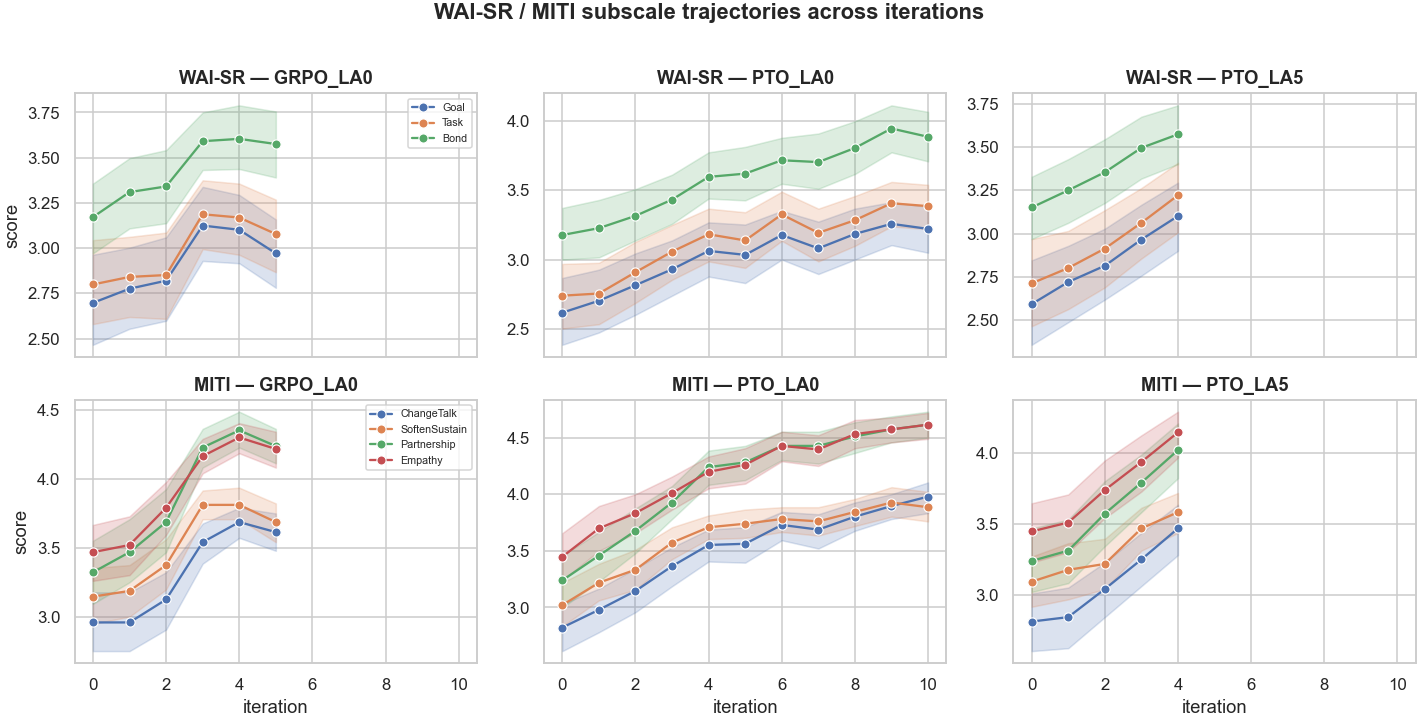

In [3]:
fig = plots.subscale_trajectory_grid(exp3.load_subscales(S.ARMS), min_iters=3)
exp3.save_fig(fig, "subscale_trajectories", caption="WAI-SR + MITI global subscale means across iterations; one panel per (parent, arm), arms with <3 scored iters omitted."); plt.show()

## 3 · Did it work? — effect vs base  `[EVAL]`
**Purpose.** Vs-base effect size per arm x rubric (forest plot; full table in `6`).

  [stats] dropping thin arms (<3 scored iters): ['GRPO_LA5']


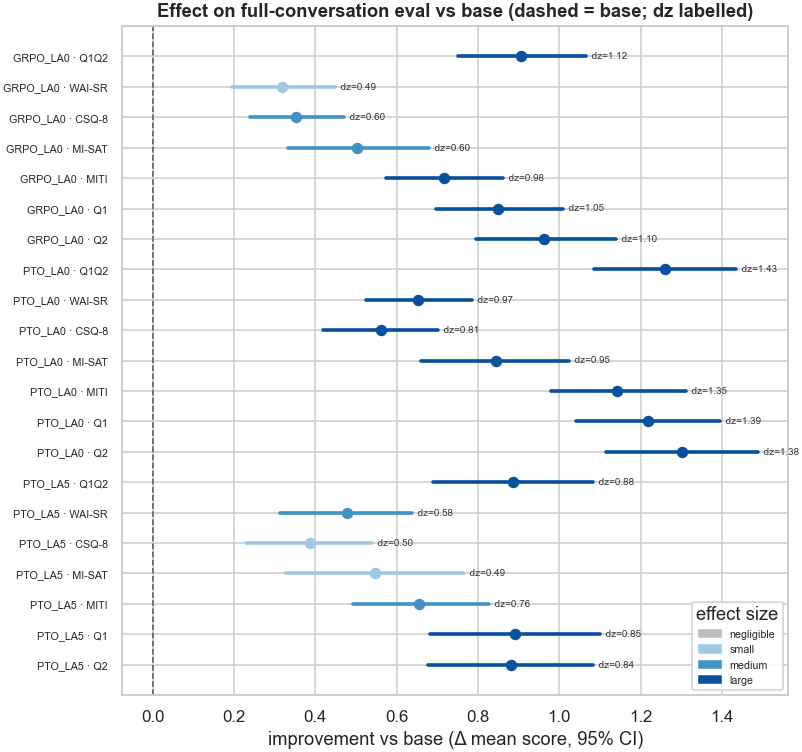

In [4]:
MR = stats.filter_thin_arms(stats.main_results_table(S.SCORES, target="final"), S.SCORES)
fig = plots.effect_forest(MR); plt.show()   # canonical save lives in 0_Headline

## 4 · PTO vs GRPO at matched look-ahead K  `[EVAL]`
**Purpose.** The core method contrast: Q1+Q2 trajectories overlaid at each matched K. **Read:** compare at the SAME iteration (equal budget); a higher endpoint may just mean more iterations.

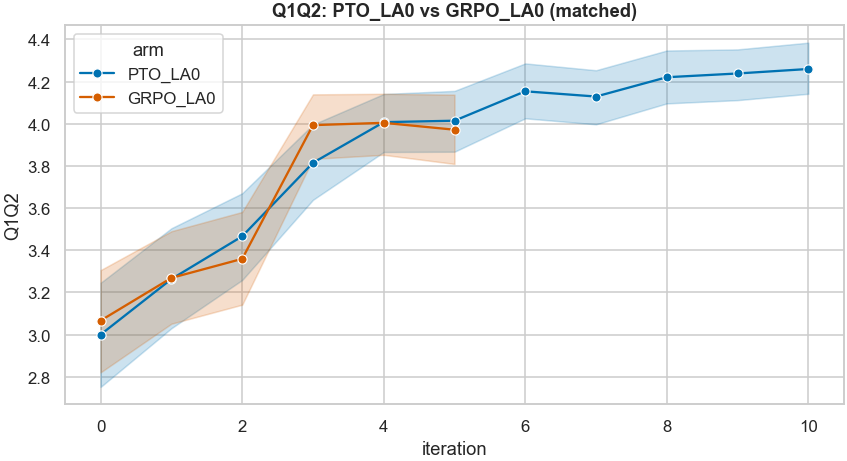

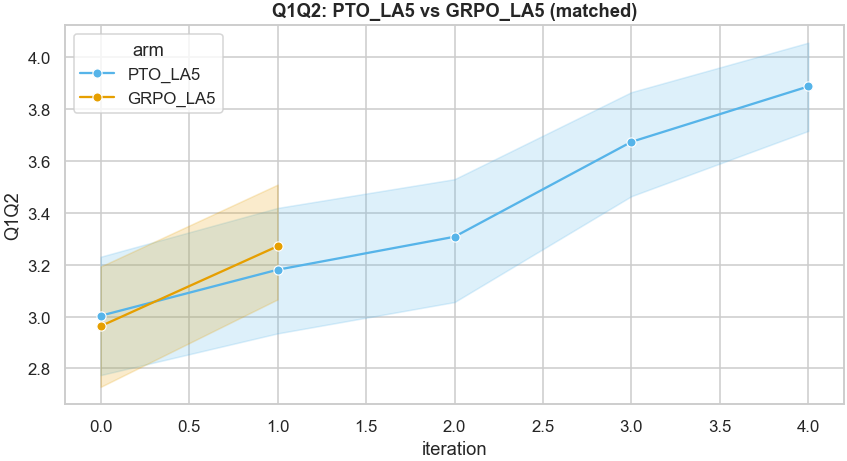

In [5]:
for K in sorted(S.SCORES.K.unique()):
    fig = plots.method_contrast_overlay(S.SCORES, "Q1Q2", pair=(f"PTO_LA{K}", f"GRPO_LA{K}"), palette=S.PALETTE)
    if fig is None: print(f"K={K}: no overlapping PTO/GRPO arms yet."); continue
    exp3.save_fig(fig, f"method_contrast_Q1Q2_LA{K}", caption=f"PTO vs GRPO Q1+Q2 trajectories at matched look-ahead K={K} (mean +/- 95% CI)."); plt.show()

## 5 · Look-ahead: K=0 vs K=5 within each method  `[EVAL]`
**Purpose.** Does anticipating K future turns help the final policy? K0 vs K5 Q1+Q2 trajectories per method. **Read:** preliminary while the LA5 arms are thin.

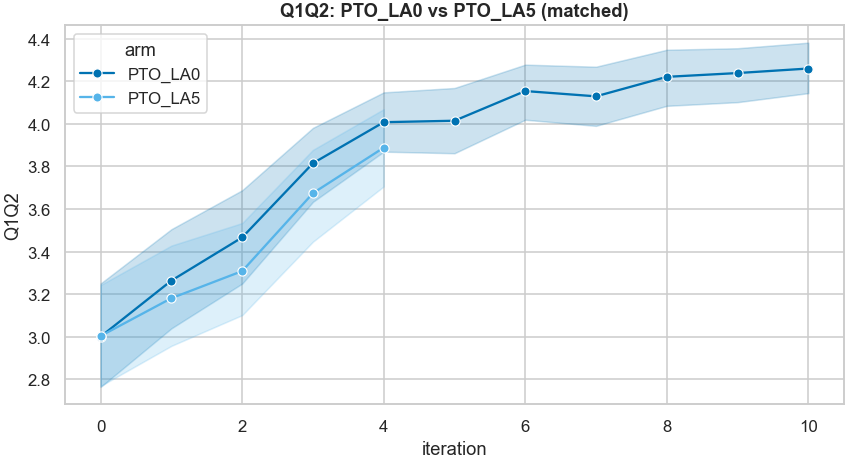

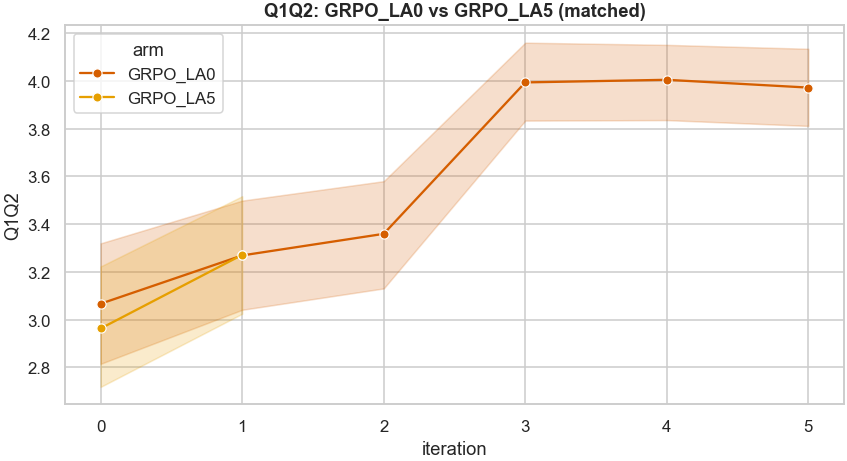

In [6]:
for method in ["PTO", "GRPO"]:
    fig = plots.method_contrast_overlay(S.SCORES, "Q1Q2", pair=(f"{method}_LA0", f"{method}_LA5"), palette=S.PALETTE)
    if fig is None: print(f"{method}: LA5 not scored yet."); continue
    exp3.save_fig(fig, f"{method}_K0_vs_K5_Q1Q2", caption=f"{method} K=0 vs K=5 Q1+Q2 trajectory (mean +/- 95% CI)."); plt.show()

## 6 · Leaderboard (best iteration per arm + Base)  `[EVAL]`
**Purpose.** Compact cross-model ranking on each rubric; each arm's best iteration + the pooled Base.

In [7]:
RANK = stats.rank_table(exp3.collapse_base(exp3.best_per_experiment(S.SCORES)[0])).round(3)
display(RANK[[c for c in RANK.columns if c in S.METRICS or c == "AvgRank"]])

,Q1Q2,WAI-SR,CSQ-8,MI-SAT,MITI,Q1,Q2,AvgRank
model,,,,,,,,
PTOExp3_LA0_I10,4.260,3.497,2.945,3.536,4.273,4.140,4.380,1.000
GRPOExp3_LA0_I4,4.004,3.292,2.751,3.266,4.039,3.898,4.111,2.143
PTOExp3_LA5_I4,3.888,3.299,2.725,3.222,3.805,3.835,3.941,2.857
GRPOExp3_LA5_I1,3.272,2.964,2.396,2.767,3.299,3.173,3.370,4.000
Base,3.008,2.853,2.360,2.688,3.156,2.950,3.067,5.000


## A · Appendix — per-model outcome bars  `[EVAL]`
The exhaustive per-model bar view (all iterations, pooled Base, dotted base line); the headline story is the trajectory grid in §1.

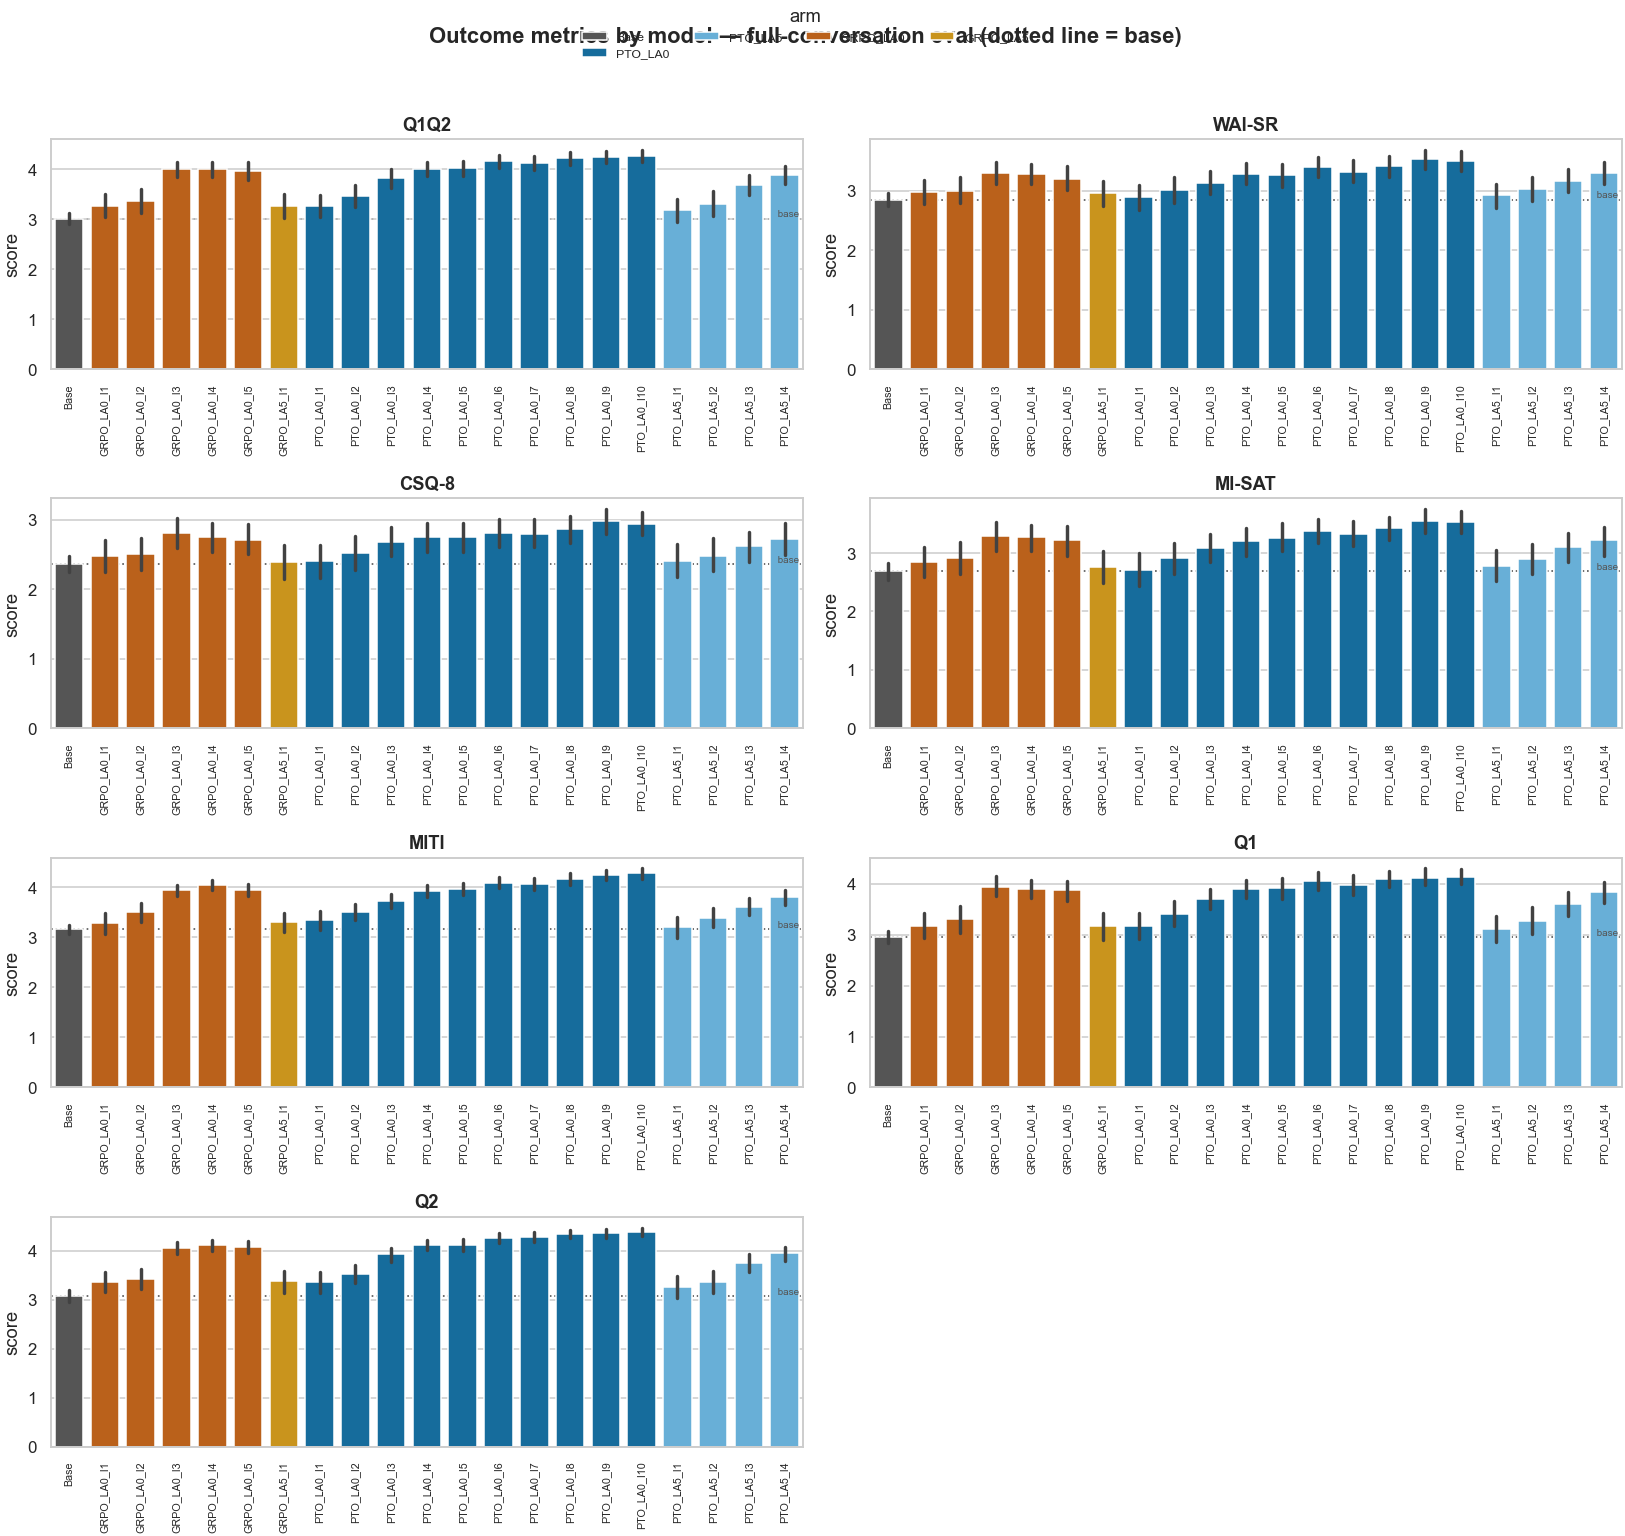

In [8]:
ALL_D = exp3.collapse_base(exp3.all_models(S.SCORES))
fig = plots.outcomes_by_model(ALL_D, palette=figures.arm_palette(sorted(ALL_D.arm.unique())), order=figures.model_order(ALL_D))
exp3.save_fig(fig, "outcomes_by_model", caption="Appendix: full-conversation eval, all models x rubrics; mean +/- 95% CI over 96 personas (arm-bases pooled into one Base; dotted line = base)."); plt.show()

## How to read this notebook
- **Trajectories (§1)** are the headline 'did it work'; **§3** gives the per-arm effect sizes.
- **§4** is the thesis's core comparison — read PTO vs GRPO at matched iterations.
- **§5** is the look-ahead lever (preliminary).
- _(Exact stats -> `6`; behaviour/why -> `2`; training signal -> `3`; reward faithfulness -> `4`.)_